In [1]:
import tensorflow as tf
from tensorflow import keras
tf.__version__

'2.9.1'

In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [4]:
x_train_full.shape

(60000, 28, 28)

In [5]:
x_train_full.dtype

dtype('uint8')

In [6]:
x_valid, x_train = x_train_full[:5000] / 255.0, x_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
x_test = x_test / 255.0

In [8]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [11]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [12]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [14]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 300)               235500    
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [15]:
model.layers

In [16]:
hidden1 = model.layers[1]

In [17]:
hidden1.name

'dense_3'

In [18]:
model.get_layer('dense_3') is hidden1

True

In [19]:
weights, biases = hidden1.get_weights()

In [22]:
weights

array([[ 0.02835891,  0.03220256, -0.03181369, ..., -0.0415177 ,
         0.06838699, -0.0703661 ],
       [ 0.06695209,  0.02928502,  0.00613409, ...,  0.02225393,
        -0.01135558,  0.07138802],
       [ 0.06307986,  0.01411547,  0.04368038, ...,  0.02358927,
        -0.02056954,  0.05769794],
       ...,
       [ 0.00203613, -0.04809378, -0.00981633, ...,  0.05135766,
         0.04206637, -0.02605985],
       [-0.00857911,  0.02826543,  0.06753851, ..., -0.07263302,
        -0.01250203, -0.07163225],
       [-0.04984023, -0.02397574, -0.07084838, ..., -0.00300957,
         0.03969385,  0.06552678]], dtype=float32)

In [23]:
weights.shape

(784, 300)

In [24]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [25]:
biases.shape

(300,)

In [26]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [27]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_valid, y_valid))

Epoch 1/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.7224 - accuracy: 0.7622 - val_loss: 0.5054 - val_accuracy: 0.8320
Epoch 2/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4857 - accuracy: 0.8300 - val_loss: 0.4445 - val_accuracy: 0.8468
Epoch 3/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4411 - accuracy: 0.8459 - val_loss: 0.4608 - val_accuracy: 0.8386
Epoch 4/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4136 - accuracy: 0.8550 - val_loss: 0.4141 - val_accuracy: 0.8586
Epoch 5/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3927 - accuracy: 0.8629 - val_loss: 0.3775 - val_accuracy: 0.8696
Epoch 6/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3769 - accuracy: 0.8682 - val_loss: 0.3811 - val_accuracy: 0.8622
Epoch 7/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3632 - accuracy: 0.8717 - val_loss: 0.3831 - val_accuracy:

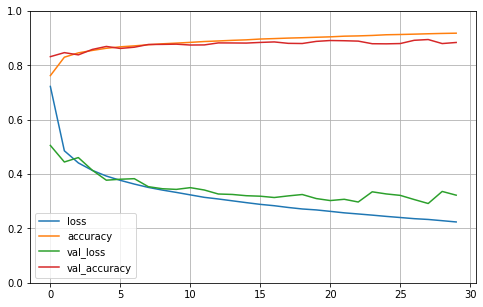

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [29]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.3562 - accuracy: 0.8730


[0.35618826746940613, 0.8730000257492065]

In [30]:
x_new = x_test[:3]
y_proba = model.predict(x_new)
y_proba.round(2)

1/1 [==============================] - 0s 104ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.99],
       [0.  , 0.  , 0.99, 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [34]:
y_pred = np.argmax(model.predict(x_new), axis=-1)
y_pred

1/1 [==============================] - 0s 24ms/step


array([9, 2, 1], dtype=int64)

In [35]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [36]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

In [37]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

x_train_full, x_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

In [38]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=x_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(loss='mean_squared_error', optimizer='sgd')
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)
x_new = x_test[:3]
y_pred = model.predict(x_new)

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 0.9995 - val_loss: 0.5257
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5179 - val_loss: 0.4643
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4559 - val_loss: 0.4391
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4666 - val_loss: 0.4286
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4278 - val_loss: 0.4201
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4395 - val_loss: 0.4292
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4228 - val_loss: 0.4221
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4121 - val_loss: 0.4051
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4072 - val_loss: 0.3995
Epoch 10/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4098 - val_loss: 0.3921

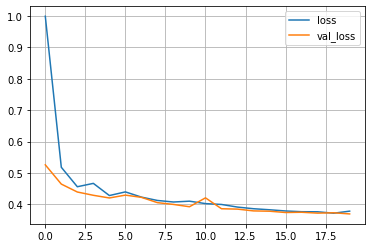

In [40]:
pd.DataFrame(history.history).plot()
plt.grid(True)
plt.show()

In [43]:
input_ = keras.layers.Input(shape=x_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation='relu')(input_)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

In [45]:
model.compile(loss='mean_squared_error', optimizer='sgd')
history = model.fit(x_train, y_train, validation_data=(x_valid, y_valid), epochs=20)
mse_test = model.evaluate(x_test, y_test)
x_new = x_test[:3]
y_pred = model.predict(x_new)

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 12507.2266 - val_loss: 1155.3002
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 3597811580928.0000 - val_loss: 76167744.0000
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 105843168.0000 - val_loss: 30148460.0000
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 29418836.0000 - val_loss: 15098104.0000
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 33834480.0000 - val_loss: 8310496.0000
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 7503094.5000 - val_loss: 3945918.5000
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 3868431.5000 - val_loss: 2074616.2500
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 6624382.0000 - val_loss: 1051682.8750
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 849101.6875 - val_loss

In [47]:
input_A = keras.layers.Input(shape=[5], name='wide_input')
input_B = keras.layers.Input(shape=[6], name='deep_input')
hidden1 = keras.layers.Dense(30, activation='relu')(input_B)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name='output')(concat)
model = keras.Model(inputs=[input_A, input_B], outputs=[output])

In [49]:
model.compile(loss='mse', optimizer=keras.optimizers.SGD(learning_rate=1e-3))

x_train_A, x_train_B = x_train[:, :5], x_train[:, 2:]
x_valid_A, x_valid_B = x_valid[:, :5], x_valid[:, 2:]
x_test_A, x_test_B = x_test[:, :5], x_test[:, 2:]
x_new_A, x_new_B = x_test_A[:3], x_test_B[:3]

history = model.fit((x_train_A, x_train_B), y_train, epochs=20, validation_data=((x_valid_A, x_valid_B), y_valid))
mse_test = model.evaluate((x_test_A, x_test_B), y_test)
y_pred = model.predict((x_new_A, x_new_B))

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 2.7646 - val_loss: 1.0456
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.8700 - val_loss: 0.7107
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6905 - val_loss: 0.6469
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6503 - val_loss: 0.6221
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6297 - val_loss: 0.6050
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6140 - val_loss: 0.5917
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6007 - val_loss: 0.5788
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5888 - val_loss: 0.5680
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5778 - val_loss: 0.5572
Epoch 10/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5678 - val_loss: 0.5484

In [57]:
input_A = keras.layers.Input(shape=[5], name='wide_input')
input_B = keras.layers.Input(shape=[6], name='deep_input')
hidden1 = keras.layers.Dense(30, activation='relu')(input_B)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name='main_output')(concat)
aux_output = keras.layers.Dense(1, name='aux_output')(hidden2)
model = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])

In [61]:
model.compile(loss=['mse','mse'], loss_weights=[0.9, 0.1], optimizer='sgd')

In [52]:
history = model.fit([x_train_A, x_train_B], [y_train, y_train], epochs=20,
                    validation_data=([x_valid_A, x_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 [==============================] - 1s 1ms/step - loss: 0.9973 - main_output_loss: 0.8539 - aux_output_loss: 2.2883 - val_loss: 0.5985 - val_main_output_loss: 0.5154 - val_aux_output_loss: 1.3465
Epoch 2/20
363/363 [==============================] - 0s 807us/step - loss: 0.5901 - main_output_loss: 0.5157 - aux_output_loss: 1.2597 - val_loss: 0.5415 - val_main_output_loss: 0.4740 - val_aux_output_loss: 1.1489
Epoch 3/20
363/363 [==============================] - 0s 821us/step - loss: 0.5471 - main_output_loss: 0.4841 - aux_output_loss: 1.1145 - val_loss: 0.5219 - val_main_output_loss: 0.4673 - val_aux_output_loss: 1.0138
Epoch 4/20
363/363 [==============================] - 0s 822us/step - loss: 0.5112 - main_output_loss: 0.4593 - aux_output_loss: 0.9784 - val_loss: 0.5549 - val_main_output_loss: 0.5150 - val_aux_output_loss: 0.9144
Epoch 5/20
363/363 [==============================] - 0s 799us/step - loss: 0.6340 - main_output_loss: 0.6052 - aux_output_loss: 0.8938 - 

In [53]:
total_loss, main_loss, aux_loss = model.evaluate([x_test_A, x_test_B], [y_test, y_test])

162/162 [==============================] - 0s 561us/step - loss: 0.3802 - main_output_loss: 0.3656 - aux_output_loss: 0.5108


In [54]:
y_pred_main, y_pred_aux = model.predict([x_new_A, x_new_B])

1/1 [==============================] - 0s 38ms/step


In [55]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
        
    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output
    
model = WideAndDeepModel()

In [58]:
model.save('my_keras_model.h5')

In [59]:
model = keras.models.load_model('my_keras_model.h5')

In [64]:
input_ = keras.layers.Input(shape=x_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation='relu')(input_)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

In [65]:
model.compile(loss='mean_squared_error', optimizer='sgd')

checkpoint_cb = keras.callbacks.ModelCheckpoint('my_keras_model.h5')
history = model.fit(x_train, y_train, validation_data=(x_valid, y_valid), epochs=20, callbacks=[checkpoint_cb])


Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 3.2984 - val_loss: 0.6834
Epoch 2/20
363/363 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 4/20
363/363 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 5/20
363/363 [==============================] - 1s 1ms/step - loss: nan - val_loss: nan
Epoch 6/20
363/363 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 10/20
363/363 [==============================] - 1s 1ms/step - loss: nan - val_loss: nan
Epoch 11/20
363/363 [==============================] 

In [66]:
import os
root_logdir = os.path.join(os.curdir, 'my_logs')

def get_run_logdir():
    import time
    run_id = time.strftime('run_%Y_%m_%d-%H_%M_%S')
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

In [67]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

x_train_full, x_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

In [68]:
input_ = keras.layers.Input(shape=x_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation='relu')(input_)
output = keras.layers.Dense(1)(hidden1)
model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss='mean_squared_error', optimizer='sgd')

tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid), callbacks=[tensorboard_cb])

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 0.8786 - val_loss: 0.5642
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 1.1464 - val_loss: 0.5366
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5144 - val_loss: 0.4634
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4741 - val_loss: 0.4551
Epoch 5/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4553 - val_loss: 0.4269
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4431 - val_loss: 0.4245
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4333 - val_loss: 0.4167
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4264 - val_loss: 0.4179
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4225 - val_loss: 0.4016
Epoch 10/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4285 - val_loss: 0.4007

In [69]:
%load_ext tensorboard

In [71]:
%tensorboard --logdir=./my_logs --port=6006

In [72]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar('my_scalar', np.sin(step / 10), step=step)
        data = (np.random.randn(100) + 2) * step / 100
        tf.summary.histogram('my_hist', data, buckets=50, step=step)
        images = np.random.rand(2, 32, 32, 3)
        tf.summary.image('my_images', images * step / 1000, step=step)
        texts = ['The step is ' + str(step), 'Its square is ' + str(step**2)]
        tf.summary.text('my_text', texts, step=step)
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio('my_audio', audio, sample_rate=48000, step=step)

In [74]:
%tensorboard --logdir=./my_logs --port=6006

Reusing TensorBoard on port 6006 (pid 17304), started 0:08:16 ago. (Use '!kill 17304' to kill it.)

In [75]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation='relu'))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [76]:
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

C:\Users\rltjq\AppData\Local\Temp/ipykernel_23900/1709004121.py:1: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)


In [77]:
keras_reg.fit(x_train, y_train, epochs=100, validation_data=(x_valid, y_valid), 
              callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(x_test, y_test)
y_pred = keras_reg.predict(x_new)

Epoch 1/100
363/363 [==============================] - 1s 2ms/step - loss: 1.2249 - val_loss: 0.6583
Epoch 2/100
363/363 [==============================] - 0s 1ms/step - loss: 0.8004 - val_loss: 0.5975
Epoch 3/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5897 - val_loss: 0.5382
Epoch 4/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5440 - val_loss: 0.5098
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5174 - val_loss: 0.4917
Epoch 6/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4992 - val_loss: 0.4764
Epoch 7/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4876 - val_loss: 0.4688
Epoch 8/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4800 - val_loss: 0.4641
Epoch 9/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4739 - val_loss: 0.4585
Epoch 10/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4690 - val_lo

363/363 [==============================] - 0s 1ms/step - loss: 0.3714 - val_loss: 0.3657
Epoch 82/100
363/363 [==============================] - 0s 1ms/step - loss: 0.3717 - val_loss: 0.3644
Epoch 83/100
363/363 [==============================] - 0s 1ms/step - loss: 0.3706 - val_loss: 0.3652
Epoch 84/100
363/363 [==============================] - 0s 1ms/step - loss: 0.3700 - val_loss: 0.3638
Epoch 85/100
363/363 [==============================] - 0s 1ms/step - loss: 0.3690 - val_loss: 0.3639
Epoch 86/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3686 - val_loss: 0.3643
Epoch 87/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3689 - val_loss: 0.3618
Epoch 88/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3675 - val_loss: 0.3642
Epoch 89/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3677 - val_loss: 0.3609
Epoch 90/100
363/363 [==============================] - 0s 1ms/step - loss: 0.3667 - val_loss: 

In [79]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    'n_hidden':[0,1,2,3],
    'n_neurons':np.arange(1,100),
    'learning_rate':reciprocal(3e-4, 3e-2)
}

rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3, n_jobs=-1)
rnd_search_cv.fit(x_train, y_train, epochs=100, validation_data=(x_valid, y_valid),
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
363/363 [==============================] - 1s 2ms/step - loss: 0.8264 - val_loss: 0.4917
Epoch 2/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5225 - val_loss: 0.4435
Epoch 3/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4323 - val_loss: 0.4127
Epoch 4/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4092 - val_loss: 0.3924
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3951 - val_loss: 0.3979
Epoch 6/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3853 - val_loss: 0.3832
Epoch 7/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3764 - val_loss: 0.3660
Epoch 8/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3680 - val_loss: 0.3575
Epoch 9/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3646 - val_loss: 0.3636
Epoch 10/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3540 - val_lo

RandomizedSearchCV(cv=3,
                   estimator=<keras.wrappers.scikit_learn.KerasRegressor object at 0x00000221536D8520>,
                   n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_frozen object at 0x000002212F12C5B0>,
                                        'n_hidden': [0, 1, 2, 3],
                                        'n_neurons': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])})

In [80]:
rnd_search_cv.best_params_

{'learning_rate': 0.011691404971044324, 'n_hidden': 2, 'n_neurons': 99}

In [81]:
rnd_search_cv.best_score_

-0.29726781447728473

In [82]:
model = rnd_search_cv.best_estimator_.model